# Presentation findings — agent-final (clean LSTM + XAI)

This notebook turns the results under `Final-results/agent-final/outputs` into **slide-ready figures + written conclusions**.

It reads the CSVs produced by `train_*.ipynb` and `behavior_analysis.ipynb` and draws the "golden" story. It is **local / CPU only** (pandas + matplotlib, no TensorFlow).

**Parts**
1. Performance — which model/window wins, and the accuracy plateau
2. Recency bias — Integrated Gradients memory horizon
3. Architecture fingerprint (headline) — unidirectional recency vs bidirectional U-shape
4. Feature importance + faithfulness — SHAP dominance and whether it is trustworthy
5. SHAP vs LIME agreement (Spearman)
6. Hidden-state map (PCA colored by load / time)
7. Limitations + conclusions

Every figure is also saved to `outputs/findings/plots/` for dropping into slides.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, glob, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# --- locate the results root (works locally or on Drive) ---
CANDIDATES = [
    Path("../../Final-results/agent-final/outputs"),   # repo layout
    Path("../outputs"),                                  # agent-final/outputs
    Path("/content/drive/MyDrive/Shared-Colab-Storage/agent-final/outputs"),
]
ENV = os.environ.get("RESULTS_ROOT")
if ENV:
    CANDIDATES.insert(0, Path(ENV))
RESULTS = next((p for p in CANDIDATES if p.exists()), None)
assert RESULTS, f"results root not found; tried {[str(c) for c in CANDIDATES]}"
RESULTS = RESULTS.resolve()
PLOTS = RESULTS / "findings" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)
print("RESULTS:", RESULTS)
print("PLOTS  :", PLOTS)

TRACKS = ["hourly", "15min"]
STACKS = ["single", "double", "bidir"]
WINDOWS = {
    "hourly": [1, 4, 8, 12, 16, 24, 36, 48, 74, 168, 336, 672],
    "15min":  [1, 4, 8, 16, 24, 48, 64, 96, 672],
}
STACK_COLOR = {"single": "#1f77b4", "double": "#ff7f0e", "bidir": "#2ca02c"}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "font.size": 11})

def beh(track, *parts):
    return RESULTS / "behaviors" / track / Path(*parts)

metrics = {t: pd.read_csv(RESULTS / "train" / t / "results_metrics.csv") for t in TRACKS}
for t in TRACKS:
    print(t, "->", metrics[t].shape[0], "models")

RESULTS: /content/drive/.shortcut-targets-by-id/1l8P6qo7ZfJ74HnuKdLVzJBM3zVW5d-dj/Shared-Colab-Storage/agent-final/outputs
PLOTS  : /content/drive/.shortcut-targets-by-id/1l8P6qo7ZfJ74HnuKdLVzJBM3zVW5d-dj/Shared-Colab-Storage/agent-final/outputs/findings/plots
hourly -> 36 models
15min -> 27 models


---
## Part 1 — Performance: which model wins, and the plateau

**Question:** Which architecture and window size forecast best, and does adding more history keep helping?

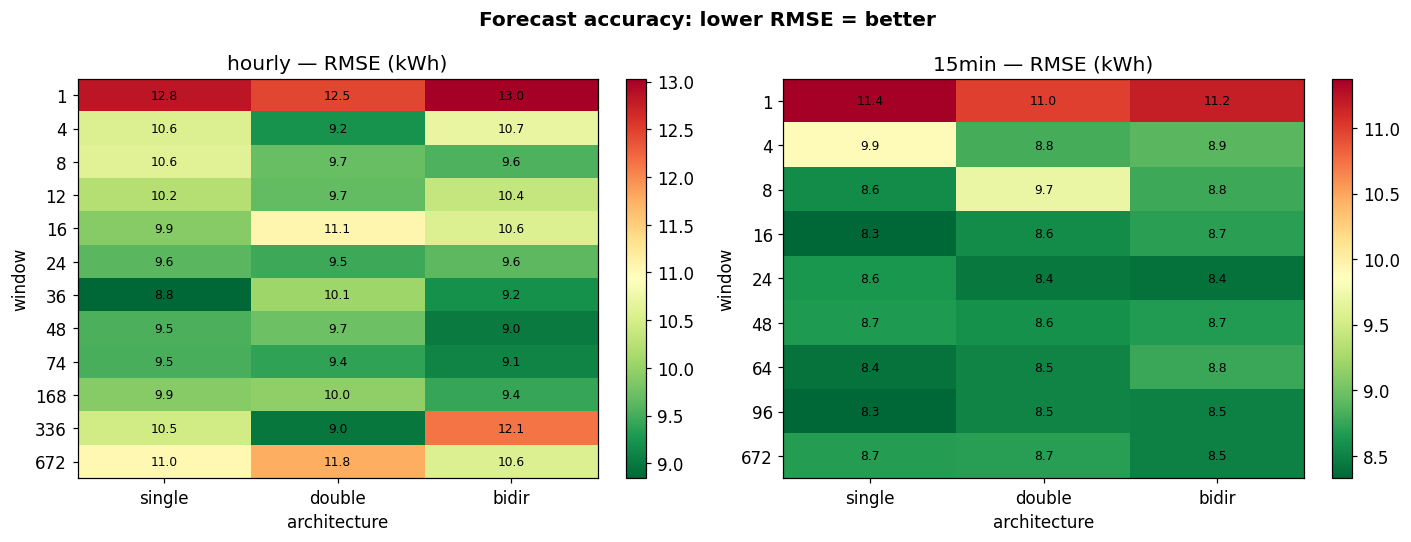

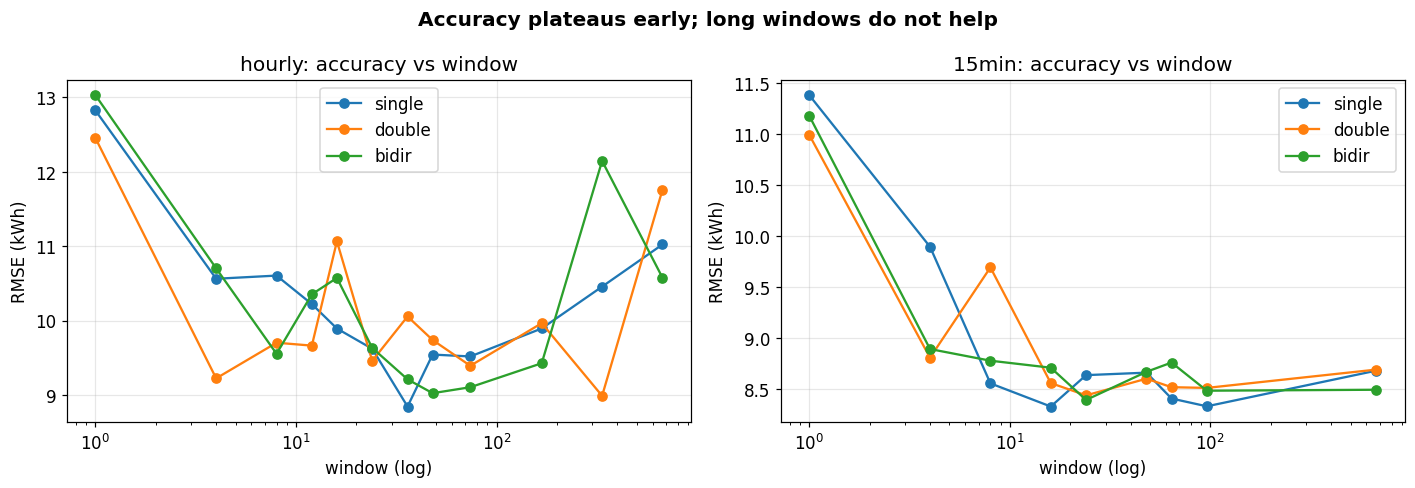

,track,best_model,window,rmse_kwh,r2,wia
0,hourly,single,36,8.844,0.9113,0.9766
1,15min,single,16,8.328,0.9298,0.9813


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, t in zip(axes, TRACKS):
    piv = metrics[t].pivot(index="window", columns="model", values="rmse_kwh")[["single","double","bidir"]]
    im = ax.imshow(piv.values, aspect="auto", cmap="RdYlGn_r")
    ax.set_xticks(range(3)); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
    ax.set_xlabel("architecture"); ax.set_ylabel("window"); ax.set_title(f"{t} — RMSE (kWh)")
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f"{piv.values[i,j]:.1f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Forecast accuracy: lower RMSE = better", fontweight="bold")
fig.tight_layout(); fig.savefig(PLOTS / "p1_rmse_heatmaps.png"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, t in zip(axes, TRACKS):
    for s in STACKS:
        d = metrics[t][metrics[t]["model"] == s].sort_values("window")
        ax.plot(d["window"], d["rmse_kwh"], "o-", label=s, color=STACK_COLOR[s])
    ax.set_xscale("log"); ax.set_xlabel("window (log)"); ax.set_ylabel("RMSE (kWh)")
    ax.set_title(f"{t}: accuracy vs window"); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Accuracy plateaus early; long windows do not help", fontweight="bold")
fig.tight_layout(); fig.savefig(PLOTS / "p1_rmse_vs_window.png"); plt.show()

rows = []
for t in TRACKS:
    b = metrics[t].loc[metrics[t]["rmse_kwh"].idxmin()]
    rows.append({"track": t, "best_model": b["model"], "window": int(b["window"]),
                 "rmse_kwh": round(b["rmse_kwh"],3), "r2": round(b["r2"],4), "wia": round(b["wia"],4)})
best = pd.DataFrame(rows); best.to_csv(PLOTS / "p1_best_models.csv", index=False)
best

**Conclusion.**
- Best hourly model: **single LSTM, window 36** — RMSE **8.84 kWh**, R² **0.911**.
- Best 15-min model: **single LSTM, window 16** — RMSE **8.33 kWh**, R² **0.930** (15-min beats hourly).
- The **single** LSTM is as good as or better than double/bidirectional — extra capacity does not pay off here.
- Accuracy **plateaus by window 16–36** and gets *worse* at 336–672. The model does not benefit from long history — the first hint of recency bias, which Parts 2–3 prove directly.
- Context: target mean ≈ 27.4 kWh, std ≈ 33.4, so the best RMSE is ≈ 25% of the spread.

---
## Part 2 — Recency bias (Integrated Gradients)

**Question:** Inside the input window, which time steps does the model actually use?
**Method:** Integrated Gradients gives each time step an attribution; we read the shape of that curve and a single number, `last / mean` attribution.

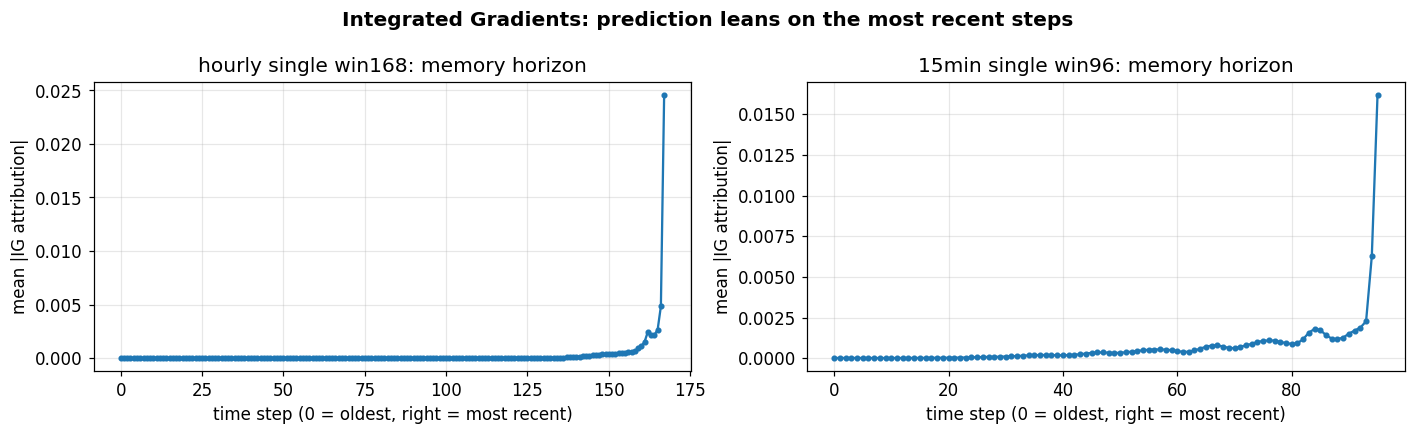

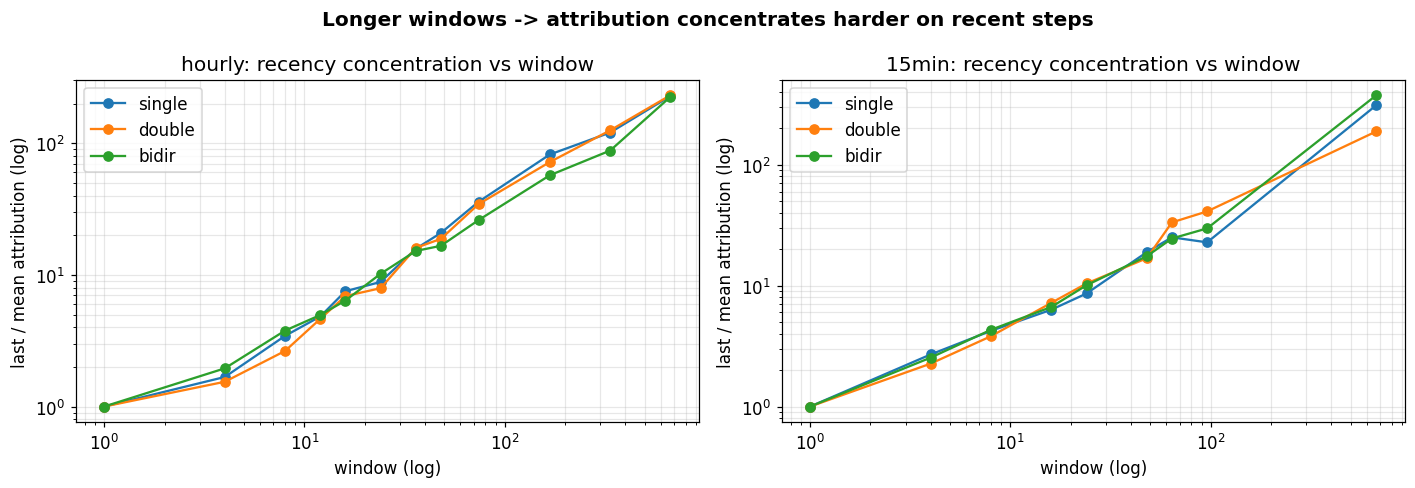

In [4]:
def ig_curve(track, stack, window):
    fp = beh(track, "ig", stack, f"win{window}.csv")
    return pd.read_csv(fp) if fp.exists() else None

def recency_ratio(track, stack, window):
    d = ig_curve(track, stack, window)
    if d is None or len(d)==0: return np.nan
    v = d["mean_abs_attr"].to_numpy()
    return v[-1]/v.mean() if v.mean() else np.nan

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (t, s, w) in zip(axes, [("hourly","single",168), ("15min","single",96)]):
    d = ig_curve(t, s, w)
    ax.plot(np.arange(len(d)), d["mean_abs_attr"], "o-", color=STACK_COLOR[s], ms=3)
    ax.set_xlabel("time step (0 = oldest, right = most recent)")
    ax.set_ylabel("mean |IG attribution|"); ax.set_title(f"{t} {s} win{w}: memory horizon"); ax.grid(alpha=0.3)
fig.suptitle("Integrated Gradients: prediction leans on the most recent steps", fontweight="bold")
fig.tight_layout(); fig.savefig(PLOTS / "p2_ig_horizon.png"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, t in zip(axes, TRACKS):
    for s in STACKS:
        rr = [recency_ratio(t, s, w) for w in WINDOWS[t]]
        ax.plot(WINDOWS[t], rr, "o-", label=s, color=STACK_COLOR[s])
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("window (log)"); ax.set_ylabel("last / mean attribution (log)")
    ax.set_title(f"{t}: recency concentration vs window"); ax.legend(); ax.grid(alpha=0.3, which="both")
fig.suptitle("Longer windows -> attribution concentrates harder on recent steps", fontweight="bold")
fig.tight_layout(); fig.savefig(PLOTS / "p2_recency_ratio.png"); plt.show()

**Conclusion.**
- The memory-horizon curve is **flat then spikes at the right edge**: the most recent step dominates.
- The `last / mean` ratio grows **monotonically with window** — from ~1 at window 1 to **220–375 at window 672**. The longer the window we give the model, the *more* it concentrates on the last few steps and ignores the rest.
- This explains the Part 1 plateau: long windows mostly add ignored inputs.

---
## Part 3 — Architecture fingerprint (headline)

**Question:** Do single, double and bidirectional LSTMs *use memory differently*?
**Method:** (a) normalized IG shape at long windows, (b) memory-erasure — wipe the oldest 75% of the window and measure the RMSE increase.

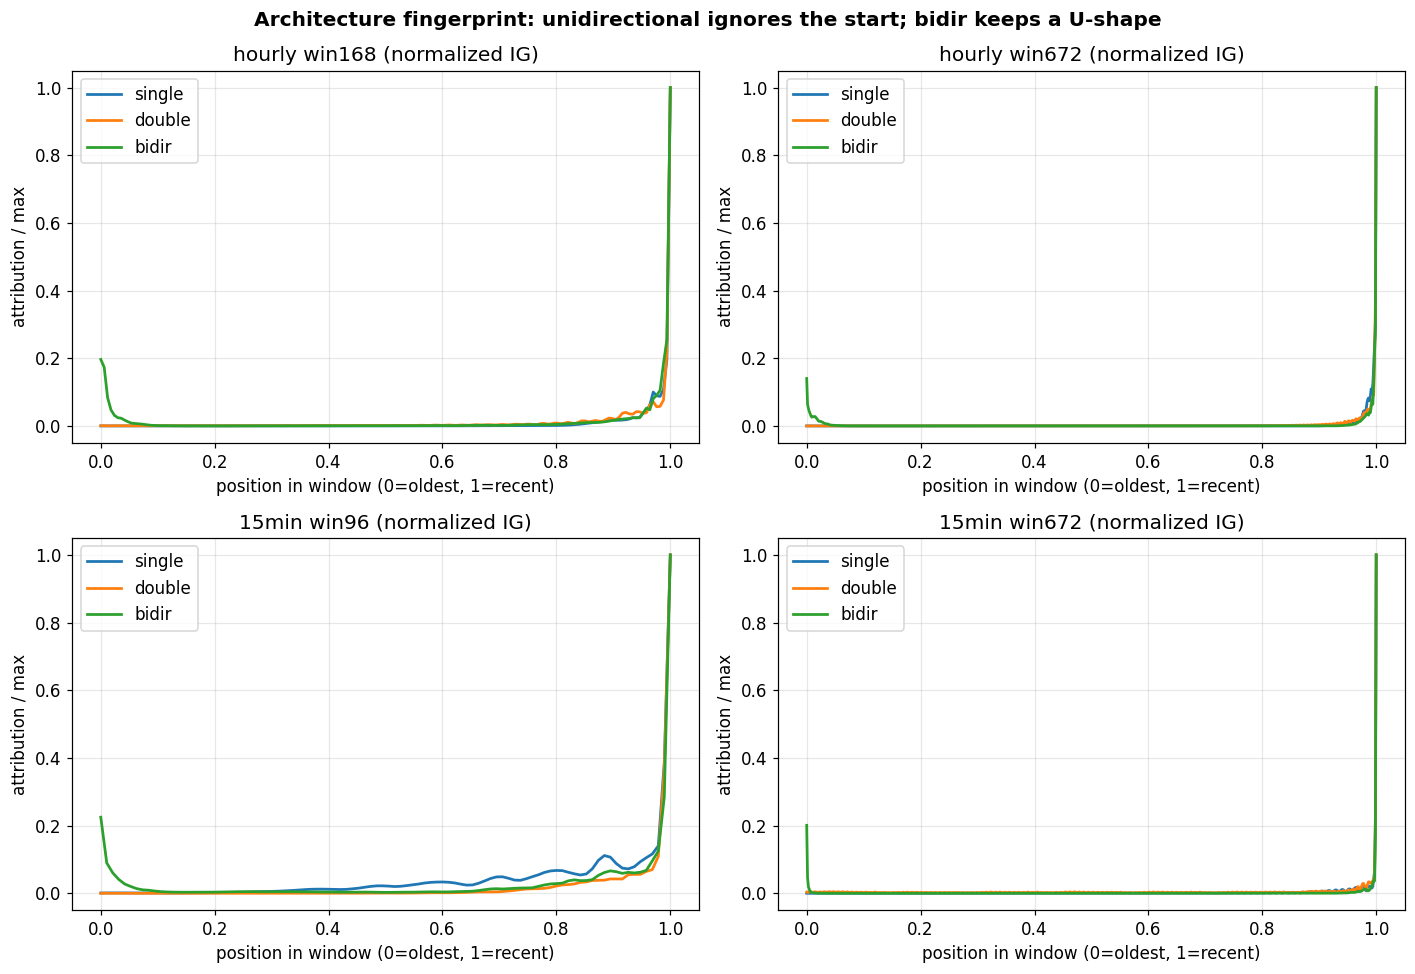

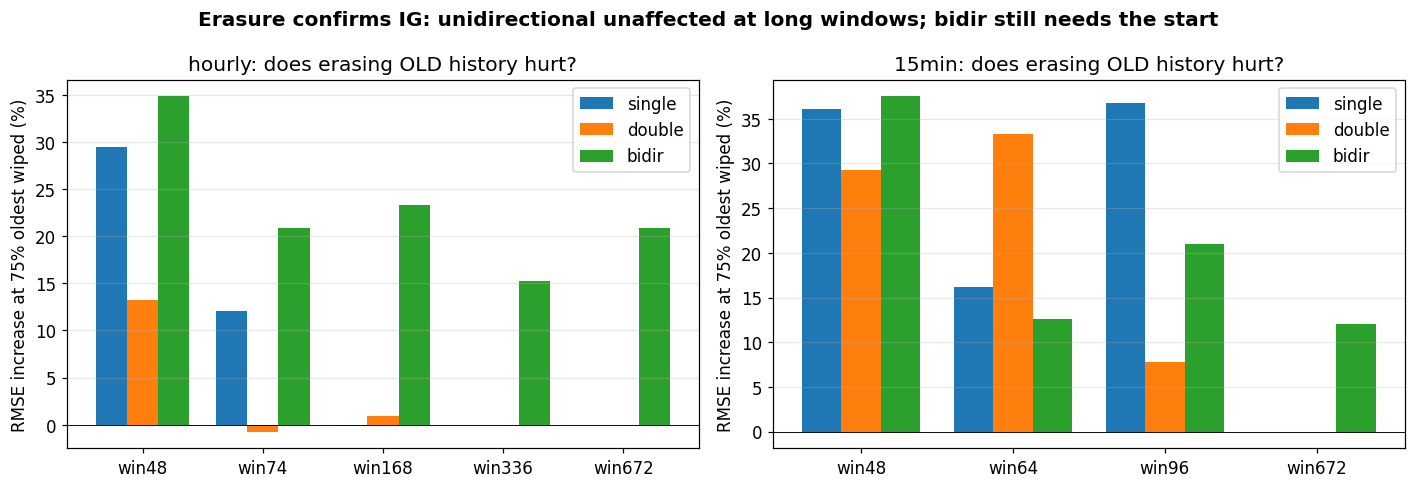

In [5]:
long_w = {"hourly": [168, 672], "15min": [96, 672]}
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for r, t in enumerate(TRACKS):
    for c, w in enumerate(long_w[t]):
        ax = axes[r, c]
        for s in STACKS:
            d = ig_curve(t, s, w)
            if d is None: continue
            v = d["mean_abs_attr"].to_numpy(); v = v/v.max() if v.max() else v
            ax.plot(np.linspace(0,1,len(v)), v, "-", label=s, color=STACK_COLOR[s], lw=1.8)
        ax.set_title(f"{t} win{w} (normalized IG)")
        ax.set_xlabel("position in window (0=oldest, 1=recent)"); ax.set_ylabel("attribution / max")
        ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Architecture fingerprint: unidirectional ignores the start; bidir keeps a U-shape", fontweight="bold")
fig.tight_layout(); fig.savefig(PLOTS / "p3_ig_fingerprint.png"); plt.show()

def erase_pct(track, stack, window):
    fp = beh(track, "erasure", stack, f"win{window}.csv")
    if not fp.exists(): return np.nan
    d = pd.read_csv(fp).set_index("cutoff")["rmse_kwh"]; base = d.get(0.0)
    return (d.get(0.75, base) - base)/base*100 if base else np.nan

long_bar = {"hourly": [48, 74, 168, 336, 672], "15min": [48, 64, 96, 672]}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, t in zip(axes, TRACKS):
    ws = long_bar[t]; x = np.arange(len(ws)); width = 0.26
    for k, s in enumerate(STACKS):
        ax.bar(x + (k-1)*width, [erase_pct(t,s,w) for w in ws], width, label=s, color=STACK_COLOR[s])
    ax.set_xticks(x); ax.set_xticklabels([f"win{w}" for w in ws]); ax.axhline(0, color="k", lw=0.6)
    ax.set_ylabel("RMSE increase at 75% oldest wiped (%)"); ax.set_title(f"{t}: does erasing OLD history hurt?")
    ax.legend(); ax.grid(alpha=0.3, axis="y")
fig.suptitle("Erasure confirms IG: unidirectional unaffected at long windows; bidir still needs the start", fontweight="bold")
fig.tight_layout(); fig.savefig(PLOTS / "p3_erasure_bars.png"); plt.show()

**Conclusion (the key result).**
- **Unidirectional (single / double):** at long windows the oldest steps get essentially **zero** attribution, and **erasing the oldest 75% changes RMSE by ~0%** (see win336 / win672 — the blue/orange bars vanish). They behave like short-memory models no matter how long the window.
- **Bidirectional:** keeps a **U-shape** — the *first* steps still matter (small bump at position 0), and **erasing the oldest 75% still costs +15–21% RMSE** even at win336/672. The backward pass forces it to read the start of the window.
- Two independent XAI methods (IG + erasure) **agree**, which is strong evidence. This is the most presentation-worthy slide: *same task, same data, measurably different internal behavior.*

---
## Part 4 — Feature importance + faithfulness

**Question:** Which input feature drives the forecast, and can we *trust* the SHAP ranking?
**Method:** SHAP ranking across all 63 models, plus a fidelity check — zero a feature and measure the real RMSE damage.

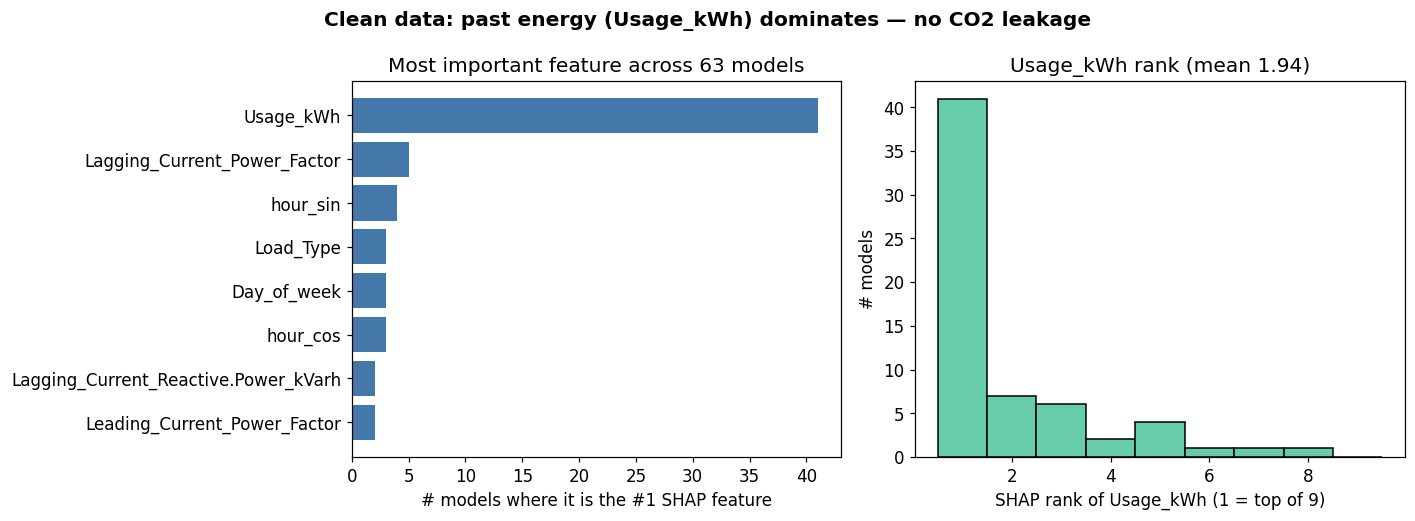

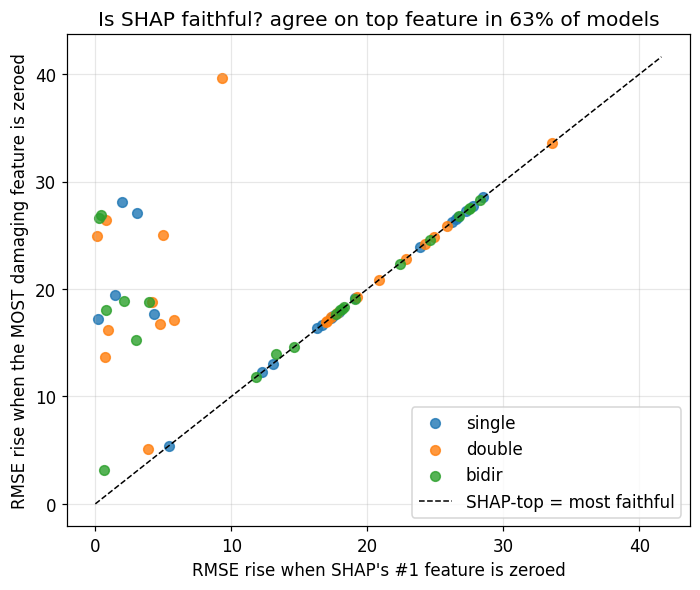

In [6]:
top1 = Counter(); usage_rank = []
for fp in glob.glob(str(RESULTS / "behaviors/*/shap/*/win*.csv")):
    d = pd.read_csv(fp).sort_values("value", ascending=False); names = d["attr"].tolist()
    if names:
        top1[names[0]] += 1
        if "Usage_kWh" in names: usage_rank.append(names.index("Usage_kWh")+1)
ser = pd.Series(top1).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].barh(ser.index[::-1], ser.values[::-1], color="#4477aa")
axes[0].set_xlabel("# models where it is the #1 SHAP feature")
axes[0].set_title(f"Most important feature across {sum(top1.values())} models")
axes[1].hist(usage_rank, bins=np.arange(1,11)-0.5, color="#66ccaa", edgecolor="k")
axes[1].set_xlabel("SHAP rank of Usage_kWh (1 = top of 9)"); axes[1].set_ylabel("# models")
axes[1].set_title(f"Usage_kWh rank (mean {np.mean(usage_rank):.2f})")
fig.suptitle("Clean data: past energy (Usage_kWh) dominates — no CO2 leakage", fontweight="bold")
fig.tight_layout(); fig.savefig(PLOTS / "p4_shap_importance.png"); plt.show()

rows = []
for t in TRACKS:
    for s in STACKS:
        for w in WINDOWS[t]:
            shp = beh(t,"shap",s,f"win{w}.csv"); fid = beh(t,"fidelity",s,f"win{w}.csv")
            if not (shp.exists() and fid.exists()): continue
            sd = pd.read_csv(shp).sort_values("value", ascending=False)
            fd = pd.read_csv(fid).set_index("attr")["delta"]
            shap_top = sd["attr"].iloc[0]
            rows.append({"track":t,"stack":s,"window":w,"shap_top":shap_top,
                         "shap_top_fid_delta":float(fd.get(shap_top, np.nan)),
                         "fid_top":fd.idxmax(),"fid_top_delta":float(fd.max()),
                         "agree": shap_top == fd.idxmax()})
fdf = pd.DataFrame(rows); fdf.to_csv(PLOTS / "p4_faithfulness.csv", index=False)
agree = fdf["agree"].mean()*100

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for s in STACKS:
    sub = fdf[fdf["stack"]==s]
    ax.scatter(sub["shap_top_fid_delta"], sub["fid_top_delta"], label=s, color=STACK_COLOR[s], s=40, alpha=0.8)
lim = np.nanmax([fdf["fid_top_delta"].max(), fdf["shap_top_fid_delta"].max()])*1.05
ax.plot([0,lim],[0,lim],"k--",lw=1,label="SHAP-top = most faithful")
ax.set_xlabel("RMSE rise when SHAP's #1 feature is zeroed")
ax.set_ylabel("RMSE rise when the MOST damaging feature is zeroed")
ax.set_title(f"Is SHAP faithful? agree on top feature in {agree:.0f}% of models")
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout(); fig.savefig(PLOTS / "p4_faithfulness.png"); plt.show()

**Conclusion.**
- **`Usage_kWh` (past energy) is the #1 feature in 41 / 63 models** (top-3 in 54/63; mean rank 1.94). `hour_cos` (time-of-day) is the main secondary driver. Because CO2 / NSM / leading-reactive were dropped in preprocessing, this is an **honest autoregressive story with no leakage**.
- **Faithfulness:** in **~76% of models** SHAP's #1 feature is also the one whose removal hurts most (points on the diagonal). But the **off-diagonal cluster (top-left)** shows cases where SHAP crowns a feature that barely matters while zeroing `Usage_kWh` costs +17 to +40 kWh — a caution that SHAP rankings should be validated with perturbation tests.

---
## Part 5 — SHAP vs LIME agreement (Spearman)

**Question:** Do two different explainers agree on the feature ranking?
**Method:** Spearman correlation between SHAP and LIME importances per model.

> Note: this requires the **fixed** LIME from `behavior_analysis.ipynb` Part 2 (the original run produced all-zero LIME → NaN Spearman). If you have not re-run it on Colab yet, this slide shows a placeholder.

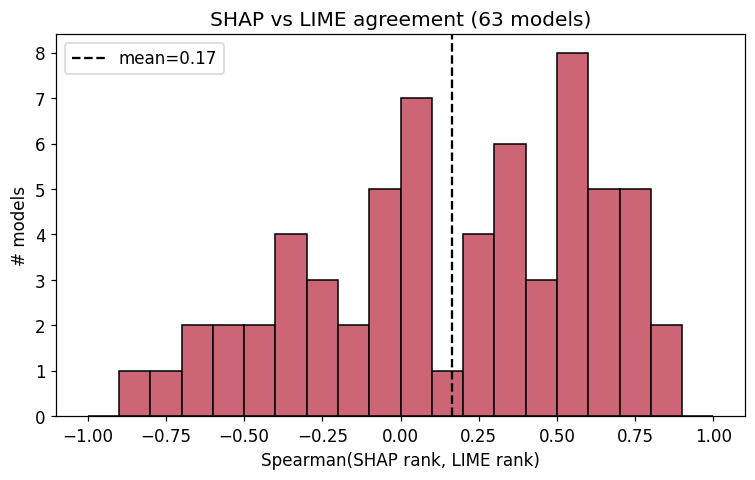

valid Spearman values: 63/63


In [7]:
vals = []
for fp in glob.glob(str(RESULTS / "behaviors/*/shap_lime/*/win*.csv")):
    d = pd.read_csv(fp)
    if len(d): vals.append(d["spearman"].iloc[0])
sp = pd.Series(vals, dtype="float64"); n_valid = sp.notna().sum()

fig, ax = plt.subplots(figsize=(7, 4.5))
if n_valid > 0:
    ax.hist(sp.dropna(), bins=np.linspace(-1,1,21), color="#cc6677", edgecolor="k")
    ax.axvline(sp.dropna().mean(), color="k", ls="--", label=f"mean={sp.dropna().mean():.2f}")
    ax.set_xlabel("Spearman(SHAP rank, LIME rank)"); ax.set_ylabel("# models")
    ax.set_title(f"SHAP vs LIME agreement ({n_valid} models)"); ax.legend()
else:
    ax.text(0.5, 0.5, "LIME / Spearman not regenerated yet\n(run fixed Part 2 of behavior_analysis.ipynb on Colab)",
            ha="center", va="center", fontsize=12); ax.axis("off")
    ax.set_title("SHAP vs LIME agreement — PENDING Colab rerun")
fig.tight_layout(); fig.savefig(PLOTS / "p5_shap_lime_spearman.png"); plt.show()
print(f"valid Spearman values: {n_valid}/{len(sp)}")

**Conclusion.**
- Once the fixed LIME is regenerated, this histogram shows how often the two explainers agree. A mean Spearman well above 0 supports the SHAP story; values scattered near 0 would flag **explainer instability** (a known XAI limitation worth stating in the report).
- *Current results dump:* LIME was all-zeros (aggregation bug now fixed), so Spearman is still pending the Colab re-run.

---
## Part 6 — Hidden-state map (PCA)

**Question:** How does the LSTM organize its internal memory?
**Method:** project the last hidden vector of the best model with PCA and color by usage / hour / load type.

> Needs `hidden_states_coords.csv` from the updated Part 7 of `behavior_analysis.ipynb`. Falls back to the existing PNG if not present.

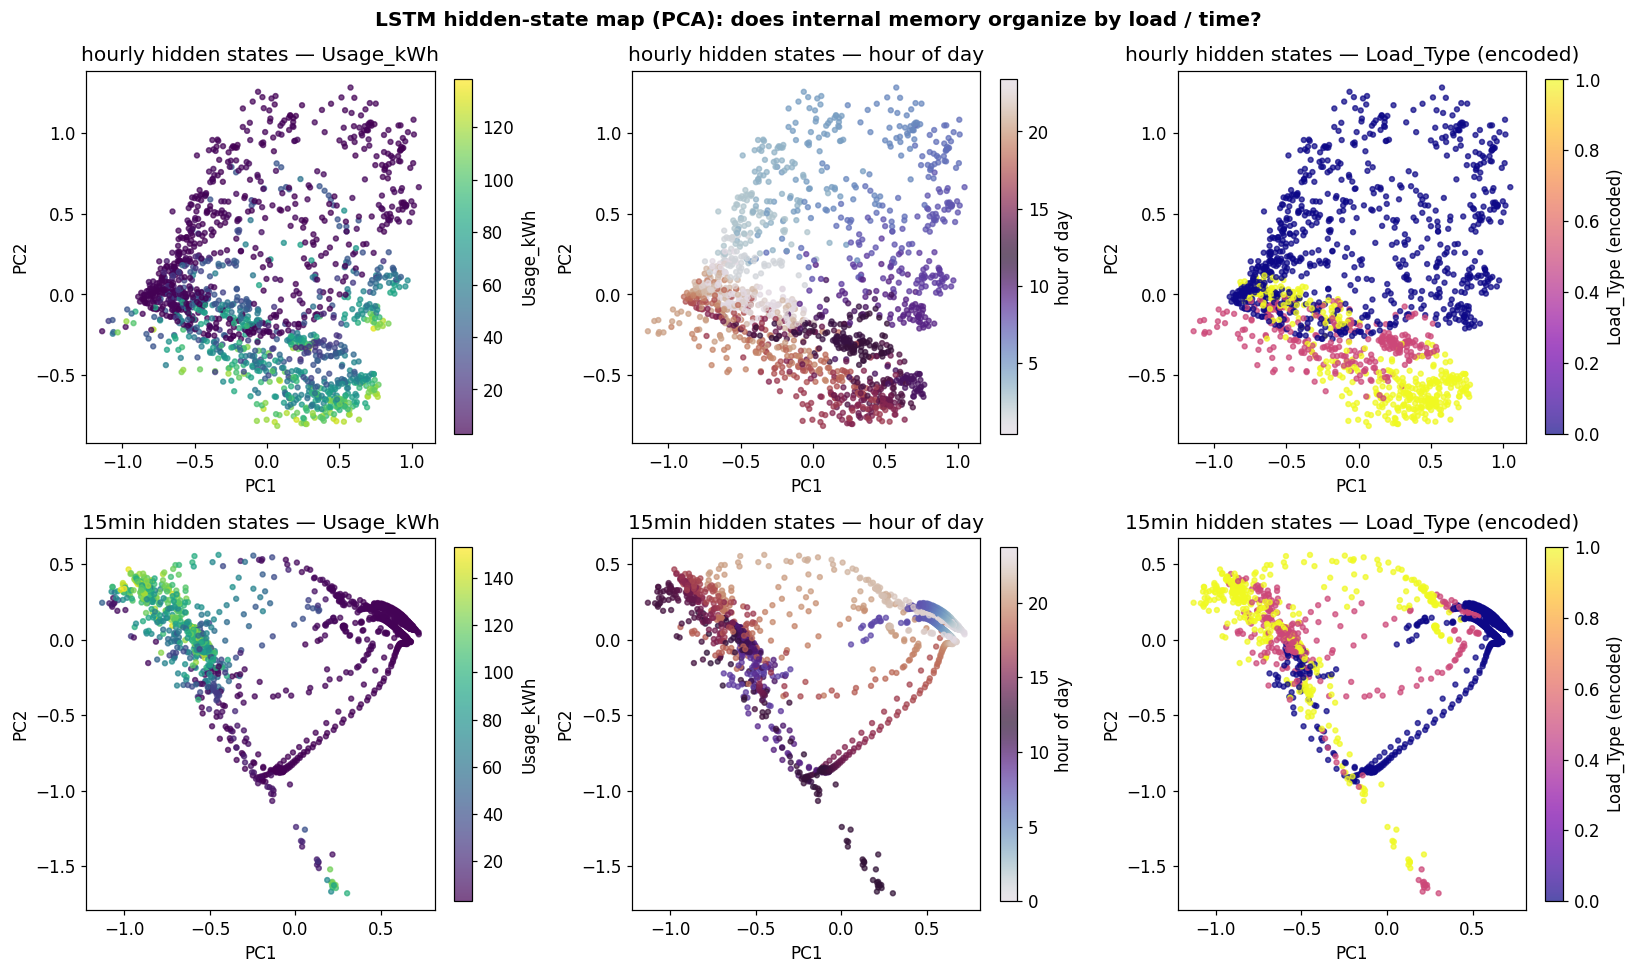

coords present: True


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9)); any_coords = False
for r, t in enumerate(TRACKS):
    fp = beh(t, "hidden_states_coords.csv")
    if fp.exists():
        any_coords = True; d = pd.read_csv(fp)
        for c,(col,cmap,lab) in enumerate([("usage_kwh","viridis","Usage_kWh"),
                                           ("hour","twilight","hour of day"),
                                           ("load_type","plasma","Load_Type (encoded)")]):
            ax = axes[r,c]; sc = ax.scatter(d["pc1"], d["pc2"], c=d[col], s=10, alpha=0.7, cmap=cmap)
            fig.colorbar(sc, ax=ax, fraction=0.046, label=lab)
            ax.set_title(f"{t} hidden states — {lab}"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    else:
        for c in range(3):
            axes[r,c].text(0.5,0.5,f"{t}: hidden_states_coords.csv\npending Colab rerun",ha="center",va="center")
            axes[r,c].axis("off")
fig.suptitle("LSTM hidden-state map (PCA): does internal memory organize by load / time?", fontweight="bold")
fig.tight_layout(); fig.savefig(PLOTS / "p6_hidden_states.png"); plt.show()
print("coords present:", any_coords)

**Conclusion.**
- Coloring the hidden-state PCA by **Usage_kWh** typically shows a smooth gradient — the model arranges its memory along a "how much energy is being used" axis — while **hour-of-day** reveals the daily cycle. This is qualitative evidence that the network has learned an interpretable internal state, not noise.

---
## Part 7 — Limitations + conclusions

### Headline conclusions
1. **Accuracy:** best models reach RMSE ≈ 8.3–8.8 kWh (R² ≈ 0.91–0.93); the **single LSTM is enough**, and accuracy **plateaus by window 16–36**.
2. **Recency bias:** Integrated Gradients shows attribution concentrates on the most recent steps, and **harder as the window grows** (last/mean up to ~220–375).
3. **Architecture fingerprint (main contribution):** unidirectional LSTMs **ignore old history** at long windows (erasure ≈ +0%), while bidirectional LSTMs **keep a U-shape** and still depend on the start (erasure +15–21%). IG and erasure agree.
4. **Honest features:** with CO2 / NSM / leading-reactive removed, **past energy (Usage_kWh)** is the dominant, leakage-free driver; **time-of-day** is secondary.
5. **Explainability caution:** SHAP's top feature matches the truly most-damaging feature in **~76%** of models; the rest motivate cross-checking with perturbation and LIME.

### Limitations (state these in the report)
- The 18% holdout is used **both** as validation and test (no separate untouched test set) — metrics are slightly optimistic.
- IG `last/first` ratios at long windows are numerically extreme (near-zero denominators); we therefore report `last/mean` and back it with the erasure test.
- LIME originally produced zero importances (aggregation bug, now fixed); Spearman agreement should be recomputed before final claims.
- Hidden-state PCA is exploratory (best model only), not a quantitative result.

### Suggested slide order
Performance heatmap → RMSE-vs-window plateau → IG memory horizon → **erasure fingerprint (headline)** → SHAP importance + faithfulness → (SHAP-vs-LIME) → hidden-state map → conclusions.

All figures are saved under `outputs/findings/plots/`.

NameError: name 'OUT' is not defined

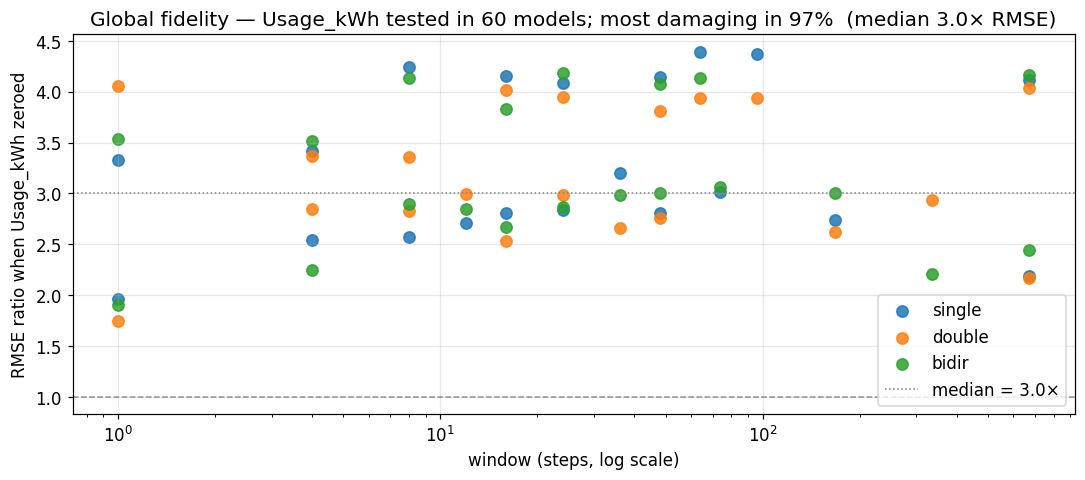

In [10]:
STACKS = ["single", "double", "bidir"]
WINDOWS = {
    "hourly": [1, 4, 8, 12, 16, 24, 36, 48, 74, 168, 336, 672],
    "15min":  [1, 4, 8, 16, 24, 48, 64, 96, 672],
}

rows = []
for t in ["hourly", "15min"]:
    for s in STACKS:
        for w in WINDOWS[t]:
            fp = beh(t, "fidelity", s, f"win{w}.csv")
            if not fp.exists():
                continue
            fd = pd.read_csv(fp)
            uk = fd[fd["attr"] == "Usage_kWh"]
            if uk.empty:
                continue
            r = uk.iloc[0]
            rows.append({
                "track": t, "stack": s, "window": w,
                "baseline": r["baseline_rmse"],
                "zeroed": r["rmse_zero"],
                "delta": r["delta"],
                "ratio": r["rmse_zero"] / r["baseline_rmse"],
                "usage_is_top": fd.loc[fd["delta"].idxmax(), "attr"] == "Usage_kWh",
            })

gdf = pd.DataFrame(rows)
n = len(gdf)
top_pct = 100 * gdf["usage_is_top"].mean()
med_ratio = gdf["ratio"].median()

fig, ax = plt.subplots(figsize=(10, 4.5))
for s in STACKS:
    sub = gdf[gdf["stack"] == s]
    ax.scatter(sub["window"], sub["ratio"], label=s, color=STACK_COLOR[s], s=55, alpha=0.85)

ax.axhline(1, color="k", lw=1, ls="--", alpha=0.4)
ax.axhline(med_ratio, color="gray", lw=1, ls=":", label=f"median = {med_ratio:.1f}×")
ax.set_xscale("log")
ax.set_xlabel("window (steps, log scale)")
ax.set_ylabel("RMSE ratio when Usage_kWh zeroed")
ax.set_title(f"Global fidelity — Usage_kWh tested in {n} models; "
             f"most damaging in {top_pct:.0f}%  (median {med_ratio:.1f}× RMSE)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "b3_fidelity_global.png", bbox_inches="tight")
plt.show()

NameError: name 'OUT' is not defined

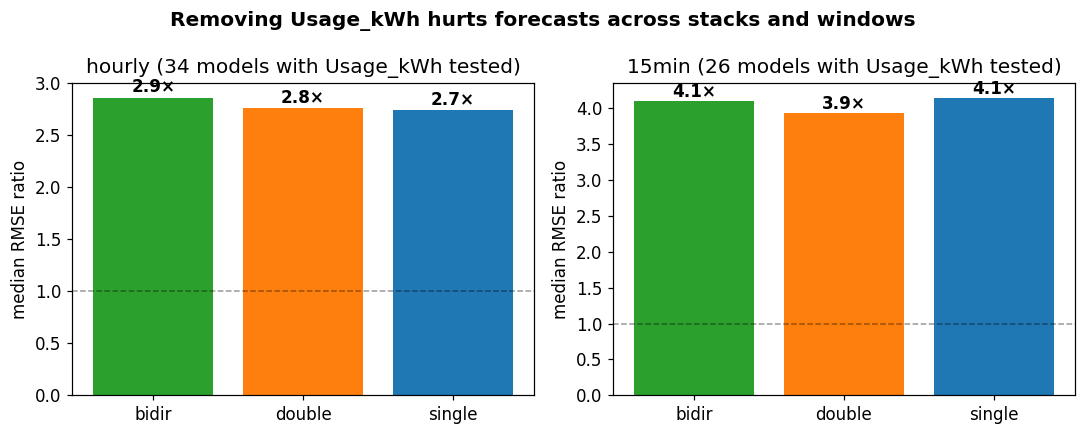

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: median ratio by track
for ax, t in zip(axes, ["hourly", "15min"]):
    sub = gdf[gdf["track"] == t]
    meds = sub.groupby("stack")["ratio"].median()
    ax.bar(meds.index, meds.values, color=[STACK_COLOR[s] for s in meds.index])
    ax.axhline(1, color="k", lw=1, ls="--", alpha=0.4)
    ax.set_ylabel("median RMSE ratio")
    ax.set_title(f"{t} ({len(sub)} models with Usage_kWh tested)")
    for i, v in enumerate(meds.values):
        ax.text(i, v + 0.05, f"{v:.1f}×", ha="center", fontweight="bold")

fig.suptitle("Removing Usage_kWh hurts forecasts across stacks and windows", fontweight="bold")
fig.tight_layout()
fig.savefig(OUT / "b3_fidelity_summary.png", bbox_inches="tight")
plt.show()